In [1]:
import mdtraj as md
import numpy as np
import scipy
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from itertools import combinations
import sys, os, re
from msmbuilder.decomposition import tICA as msm_tICA
from msmbuilder.featurizer import AtomPairsFeaturizer

sys.path.append(os.path.dirname(os.getcwd())) 
import amuset_tica

In [2]:
loaded_data = np.load("KoopmanMat-2-2-0-mix.npz")
print(loaded_data.files)
lag_times = loaded_data['lag_times']
basis_list = loaded_data['basis_list']
Ks = loaded_data['Ks']
print(Ks.shape)

['lag_times', 'basis_list', 'Ks']
(50, 25, 25)


Time = 1 ps
[254.10462670613603, 50.4714396368313, 13.308402014146079, 0.847464099074986, 0.5630386412185236]
Time = 2 ps
[410.87851414004984, 55.37856912410132, 16.11754042765571, 1.0400721681876146, 0.8523703635216091]
Time = 3 ps
[522.4445936770628, 57.3967164574249, 17.5223476885135, 1.1423178037907977, 0.9536055946707377]
Time = 4 ps
[602.812360079082, 58.46787028344545, 18.179830838917578, 1.2480525058774994, 1.1682381888790345]
Time = 5 ps
[664.934222398512, 59.107452656930406, 18.58099409228535, 1.650259590761479, 1.344266594359768]
Time = 6 ps
[714.0349036240225, 59.53542763013386, 18.7580249076775, 1.882498447602021, 1.4567795316205334]
Time = 7 ps
[755.59499127659, 59.88282052288996, 18.89185171342883, 1.6455060387898095, 1.4847466480632898]
Time = 8 ps
[788.0449827132895, 60.181583015763756, 18.88448018263999, 2.22421524633352, 1.9226263415147389]
Time = 9 ps
[816.675280296476, 60.421197313790955, 18.861467476500067, 2.3417734786247992, 2.158226852827699]
Time = 10 ps
[839.

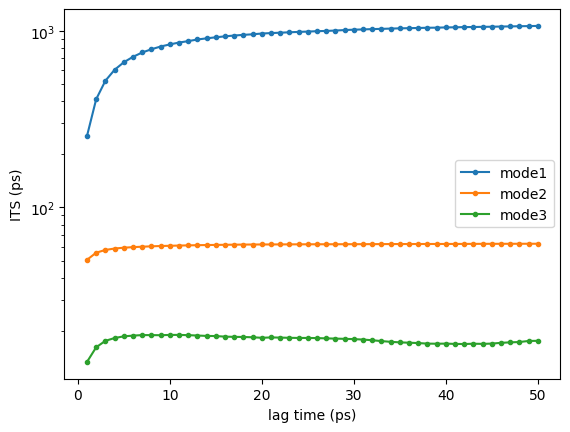

Current date and time: 2026-03-06 10:58:29.190528


In [3]:
ITSs, Es, Vs = [], [], []
for i in range(len(lag_times)):
    evK, vrK = np.linalg.eig(Ks[i])
    idx = np.argsort(evK)[::-1]
    evK = evK[idx]
    vrK = vrK[:,idx]
    
    Es.append(evK)
    Vs.append(vrK)
    print("Time =", lag_times[i], 'ps')
    ITSs.append([-lag_times[i]/np.log(Es[-1][j]) for j in range(1,6)])
    print(ITSs[-1])

fig1, ax1 = plt.subplots()
ax1.set_yscale('log')
plt.xlabel("lag time (ps)")
plt.ylabel("ITS (ps)")

ITS = np.array(ITSs).T
print("ITS.shape =", ITS.shape)
for i in range(3):#(ITS.shape[0]):
    ax1.plot(lag_times, ITS[i], '.-', label='mode'+str(i+1)) 

plt.legend()
plt.show()

from datetime import datetime
print(f"Current date and time: {datetime.now()}")

In [4]:
# ============================================================
# 1. Core regression: fit M from K(t+1) ≈ K(t) M
# ============================================================

def fit_M_from_K_sequence(Ks, st=0, gap=1, num_pair=None, enforce_hermitian_M=False, rcond=None):
    """
    Fit M in the model K(t+1) ≈ K(t) M via least squares.

    Parameters
    ----------
    Ks : list or array-like of shape [T, d, d]
        Sequence of Hermitian (or general) matrices K(t),
        t = 0, ..., T-1.
    enforce_hermitian_M : bool, optional
        If True, M is projected onto the Hermitian cone:
        M <- (M + M^†) / 2
    rcond : float or None
        Passed to np.linalg.lstsq for numerical stability.

    Returns
    -------
    M : (d, d) np.ndarray
        Estimated propagator.
    info : dict
        Some diagnostics: residuals, norms, etc.
    """
    Ks = np.asarray(Ks)
    T, d1, d2 = Ks.shape
    assert d1 == d2, "K(t) must be square."
    if st < 0:
        st = T - st
    assert gap > 0, 'gap must be positive.'
    d = d1

    if T < st + gap + 1:
        raise ValueError("Need at least 2 valid matrices K(t) to fit M.")

    # Build stacked system:
    #   X M ≈ Y
    # where X = block rows of K(0..T-2), Y = block rows of K(1..T-1)
    X = Ks[st:-gap].reshape(-1, d)
    Y = Ks[st+gap:].reshape(-1, d)

    # Solve least squares: X M ≈ Y
    # np.linalg.lstsq handles complex numbers and uses SVD internally.
    M, residuals, rank, s = np.linalg.lstsq(X, Y, rcond=rcond)

    if enforce_hermitian_M:
        M = 0.5 * (M + M.conj().T)

    # Compute residuals in matrix form: R(t) = K(t+1) - K(t) M
    R_list = []
    rel_norms = []
    end_point = T-gap
    if num_pair and num_pair < end_point - st:
        end_point = st+num_pair
    for t in range(st, end_point):
        K_pred = Ks[t] @ M
        R = Ks[t + gap] - K_pred
        R_list.append(R)
        num = np.linalg.norm(R, ord="fro")
        den = np.linalg.norm(Ks[t + gap], ord="fro") + 1e-15
        rel_norms.append(num / den)

    info = {
        "residuals": np.array(R_list),      # shape: (T-1, d, d)
        "relative_residual_norms": np.array(rel_norms),  # length T-1
        "lstsq_residuals_raw": residuals,
        "rank_X": rank,
        "singular_values_X": s,
    }

    return M, info


# ============================================================
# 2. Fit A from K(0) ≈ A M
# ============================================================

def fit_A_from_K0_and_M(K0, M):
    """
    Fit A in the model K(0) ≈ A M using pseudoinverse.

    Parameters
    ----------
    K0 : (d, d) array
        First matrix in the sequence, K(0).
    M : (d, d) array
        Propagator matrix.

    Returns
    -------
    A : (d, d) array
    """
    M_pinv = np.linalg.pinv(M)
    A = K0 @ M_pinv
    return A


# ============================================================
# 3. Generate predicted K(t) from A and M
# ============================================================

def generate_K_from_A_M(A, M, T):
    """
    Generate model-predicted K(t) = A M^t for t = 0..T-1.

    Parameters
    ----------
    A : (d, d) array
    M : (d, d) array
    T : int
        Number of time steps.

    Returns
    -------
    K_model : (T, d, d) array
    """
    d = A.shape[0]
    K_model = np.zeros((T, d, d), dtype=complex if np.iscomplexobj(A) or np.iscomplexobj(M) else float)
    Mt = np.eye(d, dtype=K_model.dtype)
    for t in range(T):
        Mt = Mt @ M
        K_model[t] = A @ Mt
    return K_model


# regression: tau_k&L, RMSE

In [13]:
def compute_rmse(diff):
    return np.sqrt(np.square(np.mean(diff)) + np.square(np.std(diff)))

RMSE_rec = np.array([[-1.] * 100 for _ in range(100)])
list_plot = [[], [], []]

rmse_steps = 20
for st in range(1, 16):
    for en in range(st+5, 25):
        M_hat, info = fit_M_from_K_sequence(Ks[:en], st, 1, enforce_hermitian_M=False)
        #print_regression_summary(info)
        A_hat = fit_A_from_K0_and_M(Ks[st], M_hat)
        Ks_model = generate_K_from_A_M(A_hat, M_hat, rmse_steps+en-st)
        
        RMSE_rec[st][en] = compute_rmse(Ks_model[en-st:]-Ks[en:rmse_steps+en])
        list_plot[0].append(st)
        list_plot[1].append(en-st)
        list_plot[2].append(RMSE_rec[st][en])
        # Optional: uncertainties
        #Ms_boot, M_mean, M_std = bootstrap_M(Ks, n_boot=200, random_state=0)


In [7]:
arr = np.array(list_plot[2])
idx = np.unravel_index(np.argmin(arr), arr.shape)[0]
print(idx, list_plot[2][idx])
print(list_plot[0][idx], list_plot[1][idx])

168 0.0017829500065351073
13 11


In [8]:
print(len(list_plot[2]))
print(np.min(list_plot[2]), np.max(list_plot[2]))

180
0.0017829500065351073 0.0025966466411447525


In [9]:
A = np.array(list_plot[2])
thr = np.percentile(A, 5)

idx = np.where(A <= thr)
print(idx[0])
print([(list_plot[0][_],list_plot[1][_]) for _ in idx[0]])

[165 166 167 168 173 174 175 178 179]
[(13, 8), (13, 9), (13, 10), (13, 11), (14, 9), (14, 10), (15, 5), (15, 8), (15, 9)]


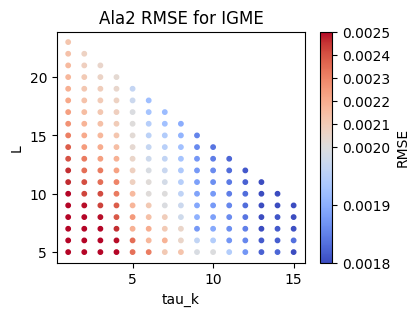

In [12]:
import matplotlib.colors as colors

plt.figure(figsize=(4,3))
norm = colors.TwoSlopeNorm(vmin=.0018, vcenter=.0020, vmax=.0025)
plt.scatter(list_plot[0], list_plot[1], s=10, c=list_plot[2], cmap="coolwarm", norm=norm)
plt.colorbar(label='RMSE')
plt.xlabel('tau_k')
plt.ylabel('L')
plt.yticks([5, 10, 15, 20])
plt.title('Ala2 RMSE for IGME')
plt.show()

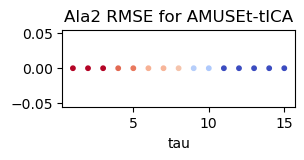

0.0014907374434430733 0.005726942851251853


In [11]:
rmse_AT = []
for i in range(1, 16):
    Ks_origin = Ks[i-1::i]
    Ks_AT_pred = [Ks[i-1]] # A.T. = amuset-tica
    for j in range(len(Ks_origin)-1):
        Ks_AT_pred.append(np.matmul(Ks[i-1], Ks_AT_pred[j]))
    rmse_AT.append(compute_rmse(Ks_AT_pred-Ks_origin))

plt.figure(figsize=(3,1))
norm = colors.TwoSlopeNorm(vmin=.0018, vcenter=.0020, vmax=.0025)
plt.scatter(range(1, 16), [0]*15, s=10, c=rmse_AT, cmap="coolwarm", norm=norm)
plt.xlabel('tau')
plt.title('Ala2 RMSE for AMUSEt-tICA')
plt.show()

print(np.min(rmse_AT), np.max(rmse_AT))

In [14]:
list_plot = np.array(list_plot)
norm_lim = [.0018, .0020, .0025]
usage = '''plt.figure(figsize=(4,3))
norm = colors.TwoSlopeNorm(vmin=.0018, vcenter=.0020, vmax=.0025)
plt.scatter(data[0], data[1], s=10, c=list_plot[2], cmap="coolwarm", norm=norm)
plt.colorbar(label='RMSE')
plt.xlabel('tau_k')
plt.ylabel('L')
plt.yticks([5, 10, 15, 20])
plt.title('Ala2 RMSE for IGME')
plt.show()'''

In [16]:
np.savez('Panel_2a1_RMSE.npz', data=list_plot, norm=norm_lim, title='Ala2 RMSE for IGME', usage = usage)

In [15]:
AT_usage = '''plt.figure(figsize=(3,1))
norm = colors.TwoSlopeNorm(vmin=.0018, vcenter=.0020, vmax=.0025)
plt.scatter(range(1, 16), [0]*15, s=10, c=data, cmap="coolwarm", norm=norm)
plt.xlabel('tau')
plt.title('Ala2 RMSE for AMUSEt-tICA')
plt.show()'''

np.savez('Panel_2a2_RMSE.npz', data=rmse_AT, norm=norm_lim, title='Ala2 RMSE for AMUSEt-tICA', usage = AT_usage)

# lag_time v.s. ITS plot

In [20]:
tics_of_trajs = np.load("Ala-lag0.1ps-first5tICs-msmbuild.npy")[:, ::10, :]
print(tics_of_trajs.shape)
print(basis_list)
print(len(lag_times))

traj_AT, traj_lens = amuset_tica._convert_sequences(tics_of_trajs)
print(traj_AT.shape)

(100, 10001, 5)
[[[-1.43747934  2.        ]
  [ 0.66571087  2.        ]
  [-0.14983666  2.        ]
  [ 5.10290513  2.        ]]

 [[-1.43747934  2.        ]
  [ 0.66571087  2.        ]
  [-0.14983666  2.        ]
  [ 5.10290513  2.        ]]]
50
(5, 1000100)


In [21]:
ttica = amuset_tica.AmusetTICA()
ITS_ = []
for i in lag_times:
    ttica.covariance(traj_AT, traj_lens, lag_time=i)
    ITS_.append(ttica.timescales_[:2])
    print(ITS_[-1])
ITS_tICA = np.array(ITS_).T
print(ITS_tICA.shape)

[4.91859361 1.97128963]
[9.12491699 2.30994585]
[13.30597559  2.48138687]
[17.51492973  2.5827773 ]
[21.6402042   2.65584227]
[25.71107396  2.72144712]
[29.58779801  2.77465318]
[33.51241286  2.83058761]
[37.12780493  2.86624901]
[40.59597834  2.89110798]
[43.69414304  2.90387717]
[46.38803272  2.87221438]
[48.8596105   2.84713846]
[50.83517473  2.97240244]
[52.41915714  3.16624237]
[53.75884858  3.3357362 ]
[54.7222289   3.41033961]
[55.50556938  3.5477689 ]
[56.13863455  3.75658076]
[56.63178901  3.66643966]
[57.027532    3.86323561]
[57.40731553  4.29340194]
[57.72582091  3.9927692 ]
[58.0048412   4.25032711]
[58.21327013  4.15234656]
[58.42414295  4.8692806 ]
[58.60087904  4.97804933]
[58.77802206  5.13415136]
[58.9361101   5.28438379]
[59.0772206   5.30648457]
[59.19400812  5.32481936]
[59.35064309  5.99428491]
[59.46505673  6.16664951]
[59.56686003  6.58787249]
[59.67529329  6.46012999]
[59.75950161  6.87028703]
[59.84292988  6.91758008]
[59.93015659  6.72089794]
[60.01941056  6.

In [22]:
ITS_Mhat = []
for i in range(5, 31):
    st = i-5 if i>=10 else i//2
    M_hat_27, _ = fit_M_from_K_sequence(Ks[:i+1], st, 1, enforce_hermitian_M=False)
    evK, vrK = np.linalg.eig(M_hat_27)
    evK = np.abs(evK)
    evK = evK[np.argsort(evK)[::-1]]
    idx = 0
    while evK[idx] - 1 > 1e-5:
        idx += 1
    cur_ITS = [-1/np.log(evK[idx+_]) for _ in range(1,6)]
    ITS_Mhat.append(cur_ITS)
    print(i, cur_ITS)
ITS_IGME = np.array(ITS_Mhat).T
print(ITS_IGME.shape)

5 [1149.133630161517, 62.00093574866071, 20.315169517495647, 3.9390909439631905, 3.9390909439631905]
6 [1148.566515071901, 61.891226331736604, 20.08183725259967, 3.659160196280111, 3.659160196280111]
7 [1144.8004051166674, 62.04419792833474, 19.83069192288458, 10.715573328088615, 2.67631832958997]
8 [1139.9348460222648, 62.19430334074239, 20.315301576891905, 3.054601331172812, 2.0224127343173985]
9 [1143.730295083961, 62.20945917040873, 20.13159761185765, 3.073293760129295, 1.7048781031248106]
10 [1143.1950052796892, 62.38151284517369, 19.338562600196553, 2.866858154171258, 1.6176868570488614]
11 [1140.471636542788, 62.464800499875786, 18.758918893409234, 2.6943291074042546, 1.9032863581598423]
12 [1146.429689345526, 62.52861639914881, 18.568554255212053, 1.6389182254547388, 1.6389182254547388]
13 [1141.338623567527, 62.576984763040734, 17.83508250928771, 1.881528053720022, 1.881528053720022]
14 [1140.6976342428159, 62.69533326289584, 17.303880169782136, 1.6638067120583686, 1.663806712

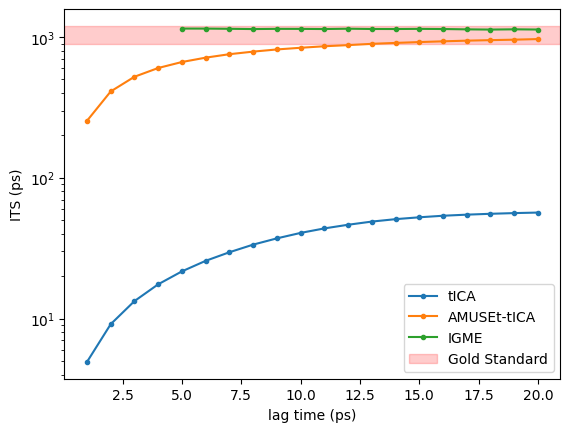

Current date and time: 2026-03-01 22:50:17.652201


In [24]:
ITS_AT = ITS

fig, ax = plt.subplots()
ax.set_yscale('log')
plt.xlabel("lag time (ps)")
plt.ylabel("ITS (ps)")

time_len = 20
ax.plot(range(1,time_len+1), ITS_tICA[0][:time_len], '.-', label='tICA')
ax.plot(range(1,time_len+1), ITS_AT[0][:time_len], '.-', label='AMUSEt-tICA')
ax.plot(range(5,time_len+1), ITS_IGME[0][:time_len-4], '.-', label='IGME') 
y_max, y_min = 900, 1200
plt.axhspan(y_min, y_max, color='red', alpha=0.2, label='Gold Standard')

plt.legend()
plt.show()

from datetime import datetime
print(f"Current date and time: {datetime.now()}")

In [25]:
usage_ITS='''
fig, ax = plt.subplots()
ax.set_yscale('log')
plt.xlabel("lag time (ps)")
plt.ylabel("ITS (ps)")

time_len = 20
ax.plot(range(1,time_len+1), ITS_tICA[0][:time_len], '.-', label='tICA')
ax.plot(range(1,time_len+1), ITS_AT[0][:time_len], '.-', label='AMUSEt-tICA')
ax.plot(range(5,time_len+1), ITS_IGME[0][:time_len-4], '.-', label='IGME') 
y_max, y_min = 900, 1200
plt.axhspan(y_min, y_max, color='red', alpha=0.2, label='Gold Standard')

plt.legend()
plt.show()
'''
np.savez('Panel_1d_ITS.npz', ITS_tICA=ITS_tICA, ITS_AT=ITS_AT, ITS_IGME=ITS_IGME, usage=usage_ITS)

In [ ]:
np.load('Panel_1d_ITS.npz')

# CVs v.s. Ramachandran angles

In [27]:
rama_angle = []
using_saved_data = False
with open("ala_rama_all_1ps.txt", "r") as rama_file:
    for line in rama_file:
        rama_angle.append(list(map(float, line.split())))
rama_angle = np.array(rama_angle).T

print(rama_angle.shape)

(2, 1000100)


In [28]:
basis_list

array([[[-1.43747934,  2.        ],
        [ 0.66571087,  2.        ],
        [-0.14983666,  2.        ],
        [ 5.10290513,  2.        ]],

       [[-1.43747934,  2.        ],
        [ 0.66571087,  2.        ],
        [-0.14983666,  2.        ],
        [ 5.10290513,  2.        ]]])

In [29]:
# if using the saved data, skip to the CVs_ generation box
using_saved_data = False
if using_saved_data:
    Vt = np.load("Ala-25-SVD-Vt.npy")
    Vt.shape

In [30]:
if not using_saved_data:
    psi_all = []
    for t in range(traj_AT.shape[1]):
        psi_t = [1.0] + [np.exp(- (traj_AT[0][t] - basis_list[0][j][0])**2 / (2 * basis_list[0][j][1]**2))
                         for j in range(len(basis_list[0]))]
        for i in range(1, len(basis_list)):
            phi_temp = [1.0] + [np.exp(- (traj_AT[i][t] - basis_list[i][j][0])**2 / (2 * basis_list[i][j][1]**2))
                         for j in range(len(basis_list[i]))]
            psi_t = np.kron(psi_t, phi_temp)
        psi_all.append(psi_t)

    Psi = np.stack(psi_all, axis=1)
    Psi.shape

In [31]:
if not using_saved_data:
    U, S, Vt = np.linalg.svd(Psi, full_matrices=False)
Vt.shape

(25, 1000100)

In [32]:
if not using_saved_data:
    np.save("Ala-25-SVD-Vt.npy", Vt)

In [ ]:
# skip to here if using the saved data
CVs_ = np.matmul(Vs[1][:, :5].T, Vt)
CVs_[0].min(), CVs_[0].max(), len(CVs_[0])

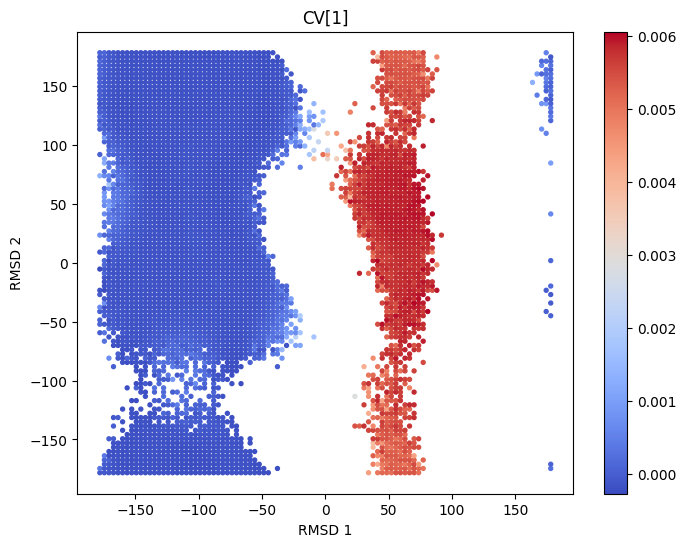

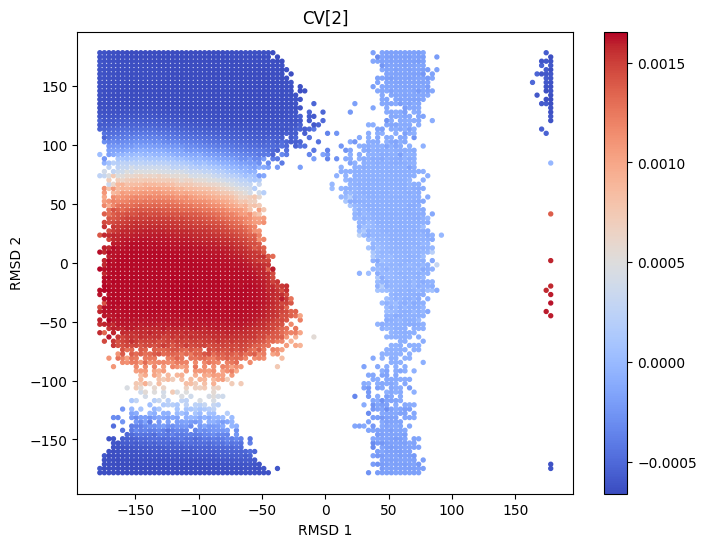

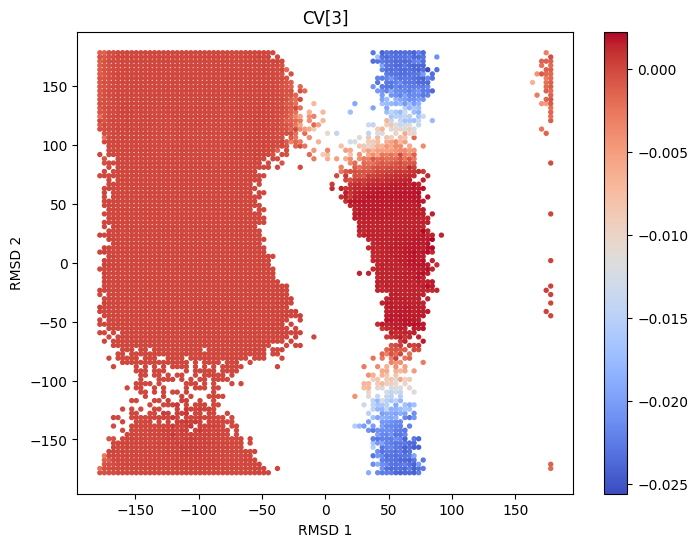

In [41]:
from scipy.stats import binned_statistic_2d

nx, ny = 100, 100
vmin = [-0.001, -0.0015, -.007]
vmean = [0.002, -0.0009, .005]
vmax = [0.005, 0.0010, .02]

for i in range(1,4):
    z_mean, x_edges, y_edges, _ = binned_statistic_2d(
        rama_angle[0], rama_angle[1], CVs_[i], statistic="mean", bins=[nx, ny]
    )

    mask = ~np.isnan(z_mean)

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    Xc, Yc = np.meshgrid(x_centers, y_centers, indexing="ij")
    
    plt.figure(figsize=(8,6))
    norm = colors.TwoSlopeNorm(vmin=vmin[i-1], vcenter=vmean[i-1], vmax=vmax[i-1])
    sc = plt.scatter(Xc[mask], Yc[mask], c=z_mean[mask], s=8, cmap="coolwarm")
    plt.colorbar(sc)
    plt.xlabel("RMSD 1")
    plt.ylabel("RMSD 2")
    plt.title(f"CV[{i}]")
    plt.show()


In [78]:
K_hat, info = fit_M_from_K_sequence(Ks[:21], 13, 1, enforce_hermitian_M=False)

K_e, K_v = np.linalg.eig(K_hat)
idx = np.argsort(K_e)[::-1]
K_e = K_e[idx]
K_v = K_v[:,idx]

CVs_Khat = np.matmul(K_v[:, :5].T, Vt)
print(K_e[:10])
print(-1.0/np.log(K_e[1:10])) # multiply by lag_time

[1.        +0.j         0.99911515+0.j         0.98417921+0.j
 0.94348705+0.j         0.67379359+0.j         0.5217846 +0.04059556j
 0.5217846 -0.04059556j 0.36192865+0.j         0.23629566+0.26041187j
 0.23629566-0.26041187j]
[1.12964087e+03-0.j         6.27066482e+01-0.j
 1.71902122e+01-0.j         2.53272626e+00-0.j
 1.52254728e+00+0.18258105j 1.52254728e+00-0.18258105j
 9.83953497e-01-0.j         5.84618140e-01+0.46645944j
 5.84618140e-01-0.46645944j]


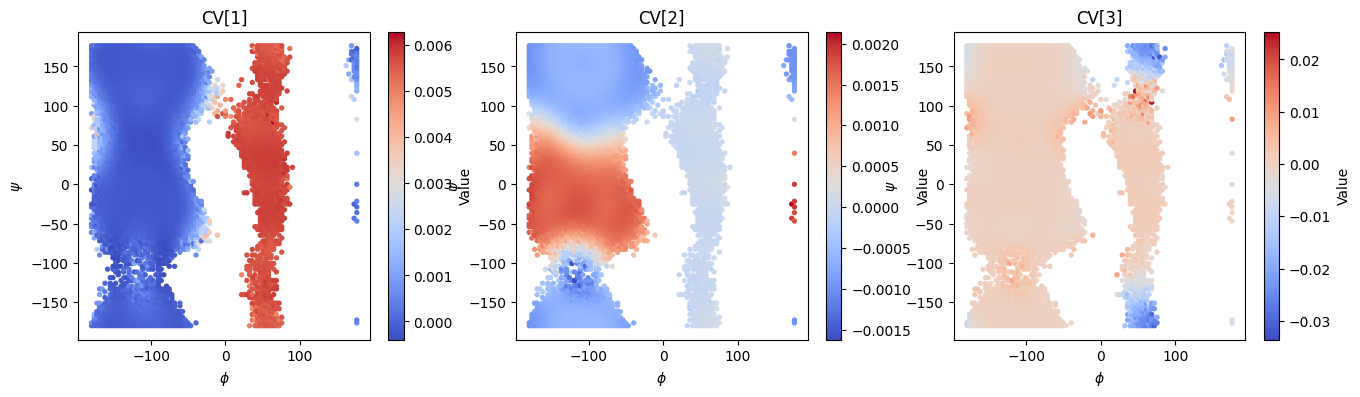

In [79]:
nx, ny = 100, 100
xmax, xmin, ymax, ymin = 180., -180., 180., -180. 

vmin = [0, -.001, -.02]
vmean = [.003, 0, 0]
vmax = [.006, .001, .02]

plots_save = []
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

x_centers = np.arange(xmin, xmax, (xmax-xmin)/nx)
y_centers = np.arange(ymin, ymax, (ymax-ymin)/ny)
Xc, Yc = np.meshgrid(x_centers, y_centers, indexing="ij")

for i, ax in enumerate(axes.ravel()):
    CVi = np.real(CVs_Khat[i+1])
    
    z_count, z_value_sum = np.zeros((nx,ny), dtype=int), np.zeros((nx,ny), dtype=np.float32)
    for j in range(len(CVi)):
        if xmin <= rama_angle[0][j] < xmax and ymin <= rama_angle[1][j] < ymax:
            x_pos = int((rama_angle[0][j] - xmin) / (xmax - xmin) * nx)
            y_pos = int((rama_angle[1][j] - ymin) / (ymax - ymin) * ny)
            z_count[x_pos][y_pos] += 1
            z_value_sum[x_pos][y_pos] += CVi[j]

    z_plot = np.zeros((nx,ny), dtype=np.float32)
    for x_idx in range(nx):
        for y_idx in range(ny):
            z_plot[x_idx][y_idx] = np.nan if z_count[x_idx][y_idx] == 0 else z_value_sum[x_idx][y_idx] / z_count[x_idx][y_idx]
    
    mask = ~np.isnan(z_plot)
    
    norm = colors.TwoSlopeNorm(vmin=vmin[i], vcenter=vmean[i], vmax=vmax[i])
    sc = ax.scatter(Xc[mask], Yc[mask], c=z_plot[mask], s=8, cmap="coolwarm")#, norm=norm)
    ax.set_xlabel(f"$\phi$")
    ax.set_ylabel(f"$\psi$")
    ax.set_title(f"CV[{i+1}]")
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Value")
    
    plots_save.append(z_plot)
    
plt.show()


In [ ]:
x_out = Xc.reshape((-1))
y_out = Yc.reshape((-1))

for i in range(len(plots_save)):
    data_output = plots_save[i].reshape((-1))
    with open(f"Ala2_pred-mode{i+1}_color.txt", "w") as f:
        f.write(f"-10 255 255 255\n")
        f.write(f"{np.nanmin(data_output)} 0 0 160\n")
        f.write(f"{vmin[i]} 0 0 255\n")
        f.write(f"{vmean[i]} 255 255 255\n")
        f.write(f"{vmax[i]} 255 0 0\n")
        f.write(f"{np.nanmax(data_output)} 160 0 0\n")
    np.nan_to_num(data_output, nan=-10, copy=False)
    with open(f"Ala2_pred-mode{i+1}_data.txt", "w") as f:
        mask = data_output == -10
        norm = colors.TwoSlopeNorm(vmin=vmin[i], vcenter=vmean[i], vmax=vmax[i])
        plt.scatter(x_out[~mask], y_out[~mask], c=data_output[~mask], s=8, cmap="coolwarm", norm=norm)
        plt.show()
        for j in range(len(data_output)):
            f.write(f"{x_out[j]:.3f} {y_out[j]:.3f} {data_output[j]:.10f}\n")
    
    print(f"CV[{i+1}] done")
